<a href="https://colab.research.google.com/github/ashok-bisht/Context-Aware_Misinformation_Detection_ML_and_Gen_AI/blob/main/notebooks/3.2_fake_news_detection_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection Pipeline

End-to-end pipeline: load data from Google Drive → clean text → EDA →
classical ML models (LR / NB / SVM / RF / XGBoost) + DistilBERT →
model comparison → TF-IDF feature importance → export CSVs for Tableau →
pickle self-contained predictors for standalone use → Streamlit app.

**Expected input CSV schema:** `,title,text,label` (first column is an index),
`label = 0` → fake news, `label = 1` → true news.


### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


## 0. Setup — install dependencies

In [ ]:
!pip -q install -U scikit-learn xgboost spacy transformers datasets torch accelerate seaborn wordcloud
!python -m spacy download en_core_web_sm -q



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\bisht\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\bisht\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


### Imports

In [ ]:
import os
import re
import sys
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


### Project configuration — **edit these paths to match your Drive layout**

Everything the pipeline reads/writes lives under `BASE_DIR`. Sub-folders are
created automatically if missing.

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Fake News Predictor"

INPUT_CSV      = f"{BASE_DIR}/data/raw/WELFake_Dataset.csv"          # your source csv (,title,text,label)
PROCESSED_DIR  = f"{BASE_DIR}/data/processed"
CLEANED_CSV    = f"{PROCESSED_DIR}/cleaned_data.csv"

CHARTS_DIR     = f"{BASE_DIR}/outputs/charts"
TABLEAU_DIR    = f"{BASE_DIR}/outputs/tableau_data"
REPORTS_DIR    = f"{BASE_DIR}/outputs/reports"
PICKLES_DIR    = f"{BASE_DIR}/models/pickles"
PIPELINE_MODULE_PATH = f"{BASE_DIR}/fake_news_pipeline.py"      # importable module for pickled predictors

for d in [PROCESSED_DIR, CHARTS_DIR, TABLEAU_DIR, REPORTS_DIR, PICKLES_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42
LABEL_MEANING = {0: "Fake News", 1: "True News"}
print("Project folders ready under:", BASE_DIR)


Project folders ready under: C:\Ashok\cdac Feb 2026\Project\Fake news prediction


## 1. Load data & build `content` field

In [ ]:
raw_df = pd.read_csv(INPUT_CSV, index_col=0)  # first unnamed column is the index
print(raw_df.shape)
raw_df.head()


(72134, 3)


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
assert {"title", "text", "label"}.issubset(raw_df.columns), \
    f"Expected columns title/text/label, got: {list(raw_df.columns)}"

df = raw_df.copy()
df["title"] = df["title"].fillna("")
df["text"]  = df["text"].fillna("")
df["content"] = (df["title"].str.strip() + ". " + df["text"].str.strip()).str.strip()

df = df[["content", "label"]].dropna(subset=["content", "label"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)

print(df.shape)
print(df["label"].value_counts())
df.head()


(72134, 2)
label
1    37106
0    35028
Name: count, dtype: int64


,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,. Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


## 2. Write the shared `fake_news_pipeline.py` module to Drive

This file is the **single source of truth** for cleaning + spaCy lemmatization
+ the `FakeNewsPredictor` bundle class. It is written programmatically
(instead of via `%%writefile`, which can't interpolate the `PIPELINE_MODULE_PATH`
variable) so the exact code used here for training is also what gets imported
later when a pickle is unpickled — in this notebook, in a standalone script,
or in Streamlit.

In [ ]:
PIPELINE_SOURCE = r'''"""
fake_news_pipeline.py
----------------------
Single source of truth for the fake-news detection inference pipeline.
Must be importable (on sys.path) wherever a FakeNewsPredictor pickle is loaded.
"""

import re


def strip_journalism_fingerprints(text, publishers_to_scrub=None):
    if not isinstance(text, str):
        return ""

    text = re.sub(r"\.\s*featured\s+image.*$", ".", text, flags=re.IGNORECASE | re.MULTILINE)
    text = re.sub(r"\s*\[\s*video\s*\]\s*", " ", text, flags=re.IGNORECASE).strip()

    text = text.strip()
    text = text.replace("\u00a0", " ")

    punctuation_map = {
        "\u2019": "'", "\u2018": "'",
        "\u201c": '"', "\u201d": '"',
        "\u2013": "-", "\u2014": "-",
    }
    for curly, straight in punctuation_map.items():
        text = text.replace(curly, straight)
    text = text.replace("\u00e2\u20ac\u2122", "'")

    text = re.sub(
        r"\b(isn|don|didn|doesn|can|wasn|weren|haven|hasn|hadn|won|wouldn|shouldn|couldn|aren)\s+t\b",
        r"\1't", text, flags=re.IGNORECASE
    )
    text = re.sub(r"\b(don|didn|doesn|isn|can)\s*'\s*t\b", r"\1't", text, flags=re.IGNORECASE)

    leading_bracket_pattern = r"^\([^)]+\)\s*"
    text = re.sub(leading_bracket_pattern, "", text)

    dateline_pattern = r"^[A-Z\s,]+(?:\s\([^)]+\))?\s*[\s\-\-\u2013\u2014]\s*"
    text = re.sub(dateline_pattern, "", text)

    byline_pattern = r"(?:By\s+[A-Za-z\s]+)?\s*\([^)]+\)"
    text = re.sub(byline_pattern, "", text)

    if publishers_to_scrub:
        escaped_publishers = [re.escape(pub) for pub in publishers_to_scrub]
        scrub_pattern = r"\b(" + "|".join(escaped_publishers) + r")\b"
        text = re.sub(scrub_pattern, "XYZ", text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", text).strip()
    return text


def spacy_lemmatize(text, nlp, min_token_len=2):
    if not text:
        return ""
    doc = nlp(text)
    tokens = [
        tok.lemma_.lower().strip()
        for tok in doc
        if not tok.is_stop
        and not tok.is_punct
        and not tok.is_space
        and not tok.like_num
        and len(tok.lemma_.strip()) >= min_token_len
    ]
    return " ".join(tokens)


class FakeNewsPredictor:
    """Bundles cleaning + spaCy lemmatization + fitted TF-IDF + fitted classical model.
    predict() takes raw text and returns {label, meaning, confidence}."""

    LABEL_MEANING = {0: "Fake News", 1: "True News"}

    def __init__(self, tfidf_vectorizer, model, model_name="model",
                 spacy_model_name="en_core_web_sm", publishers_to_scrub=None,
                 label_map=None):
        self.tfidf_vectorizer = tfidf_vectorizer
        self.model = model
        self.model_name = model_name
        self.spacy_model_name = spacy_model_name
        self.publishers_to_scrub = publishers_to_scrub
        self.label_map = label_map or self.LABEL_MEANING
        self._nlp = None

    def _get_nlp(self):
        if self._nlp is None:
            import spacy
            try:
                self._nlp = spacy.load(self.spacy_model_name, disable=["ner", "parser"])
            except OSError:
                import subprocess
                subprocess.run(["python", "-m", "spacy", "download", self.spacy_model_name], check=True)
                self._nlp = spacy.load(self.spacy_model_name, disable=["ner", "parser"])
        return self._nlp

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_nlp"] = None
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        self._nlp = None

    def preprocess(self, raw_text):
        cleaned = strip_journalism_fingerprints(raw_text, self.publishers_to_scrub)
        lemmatized = spacy_lemmatize(cleaned, self._get_nlp())
        return lemmatized

    def predict(self, raw_text):
        processed = self.preprocess(raw_text)
        X = self.tfidf_vectorizer.transform([processed])

        pred_label = int(self.model.predict(X)[0])

        if hasattr(self.model, "predict_proba"):
            proba = self.model.predict_proba(X)[0]
            confidence = float(max(proba))
        elif hasattr(self.model, "decision_function"):
            import numpy as np
            score = self.model.decision_function(X)[0]
            confidence = float(1 / (1 + np.exp(-score)))
        else:
            confidence = 1.0

        return {
            "label": pred_label,
            "meaning": self.label_map.get(pred_label, str(pred_label)),
            "confidence": round(confidence, 4),
        }

    def predict_batch(self, raw_texts):
        return [self.predict(t) for t in raw_texts]

    def __repr__(self):
        return f"<FakeNewsPredictor model={self.model_name}>"
'''

with open(PIPELINE_MODULE_PATH, "w") as f:
    f.write(PIPELINE_SOURCE)

print("Wrote pipeline module to:", PIPELINE_MODULE_PATH)


Wrote pipeline module to: C:\Ashok\cdac Feb 2026\Project\Fake news prediction/fake_news_pipeline.py


In [ ]:
# Make the Drive folder importable, then import the freshly written module
import importlib

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

import fake_news_pipeline as fnp
importlib.reload(fnp)

# sanity check on the provided cleanup function
sample = "NEW YORK (Reuters) - The senator said he isn t going to run. [VIDEO] Featured image via Al Drago-Pool/Getty Images"
print(fnp.strip_journalism_fingerprints(sample))


The senator said he isn't going to run. Featured image via Al Drago-Pool/Getty Images


## 3. Apply cleaning to `content` and save the cleaned CSV

In [ ]:
PUBLISHERS_TO_SCRUB = None  # e.g. ["Reuters", "Al Jazeera"] if you want publisher names scrubbed

df["content_clean"] = df["content"].apply(lambda t: fnp.strip_journalism_fingerprints(t, PUBLISHERS_TO_SCRUB))

# drop rows that became empty after cleaning
df = df[df["content_clean"].str.strip().str.len() > 0].reset_index(drop=True)

cleaned_df = df[["content_clean", "label"]].rename(columns={"content_clean": "content"})
cleaned_df.to_csv(CLEANED_CSV, index=False)
print("Saved cleaned data ->", CLEANED_CSV, cleaned_df.shape)
cleaned_df.head()


Saved cleaned data -> C:\Ashok\cdac Feb 2026\Project\Fake news prediction/data/processed/cleaned_data.csv (72134, 2)


,content,label
0,Following Threats Against Cops And Whites On 9...,1
1,. Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA'S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,2: Russia unvelis an image of its terrifying n...,1


## 4. Exploratory Data Analysis

In [ ]:
cleaned_df["word_count"] = cleaned_df["content"].str.split().str.len()
cleaned_df["char_count"] = cleaned_df["content"].str.len()
cleaned_df["label_name"] = cleaned_df["label"].map(LABEL_MEANING)

eda_summary = cleaned_df.groupby("label_name").agg(
    n_articles=("content", "count"),
    avg_word_count=("word_count", "mean"),
    median_word_count=("word_count", "median"),
    avg_char_count=("char_count", "mean"),
).reset_index()
eda_summary.to_csv(f"{TABLEAU_DIR}/eda_summary.csv", index=False)
eda_summary


,label_name,n_articles,avg_word_count,median_word_count,avg_char_count
0,Fake News,35028,583.396397,434.0,3515.173062
1,True News,37106,508.925834,375.0,3063.489274


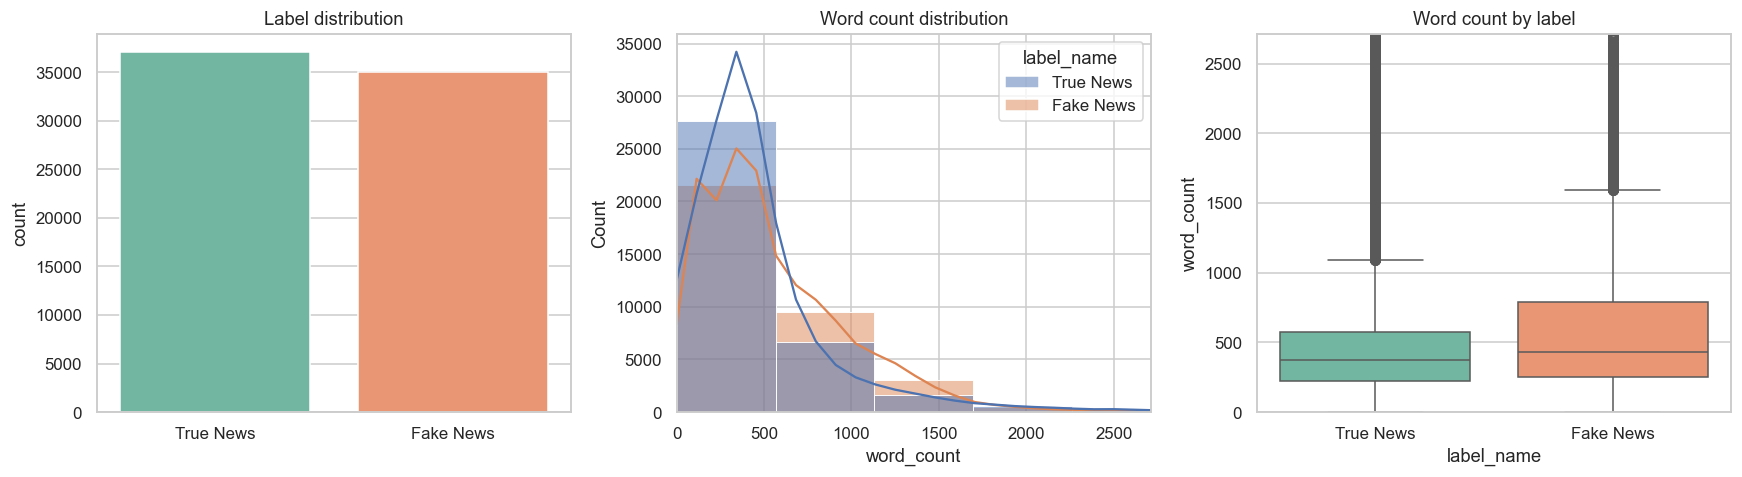

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(data=cleaned_df, x="label_name", ax=axes[0], palette="Set2")
axes[0].set_title("Label distribution")
axes[0].set_xlabel("")

sns.histplot(data=cleaned_df, x="word_count", hue="label_name", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Word count distribution")
axes[1].set_xlim(0, cleaned_df["word_count"].quantile(0.99))

sns.boxplot(data=cleaned_df, x="label_name", y="word_count", ax=axes[2], palette="Set2")
axes[2].set_title("Word count by label")
axes[2].set_ylim(0, cleaned_df["word_count"].quantile(0.99))

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/eda_overview.png", bbox_inches="tight")
plt.show()

# raw per-article data for Tableau
cleaned_df[["label", "label_name", "word_count", "char_count"]].to_csv(
    f"{TABLEAU_DIR}/eda_per_article.csv", index=False
)


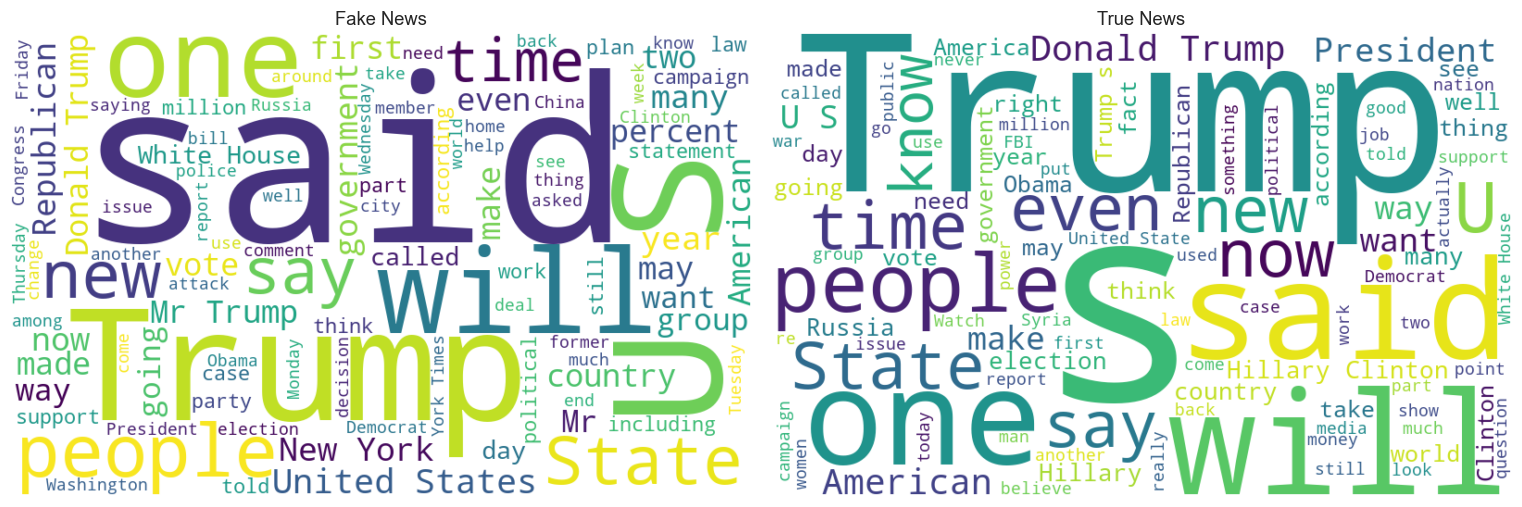

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lbl in zip(axes, [0, 1]):
    text_blob = " ".join(cleaned_df.loc[cleaned_df["label"] == lbl, "content"].sample(
        min(2000, (cleaned_df["label"] == lbl).sum()), random_state=RANDOM_STATE
    ))
    wc = WordCloud(width=800, height=500, background_color="white", max_words=100).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(LABEL_MEANING[lbl])

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/wordclouds.png", bbox_inches="tight")
plt.show()


## 5. spaCy preprocessing + TF-IDF vectorization

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm", disable=["tok2vec","ner", "parser"])

# batched lemmatization for speed
def batch_lemmatize(texts, nlp, batch_size=200, n_process=1):
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
        tokens = [
            tok.lemma_.lower().strip()
            for tok in doc
            if not tok.is_stop and not tok.is_punct and not tok.is_space
            and not tok.like_num and len(tok.lemma_.strip()) >= 2
        ]
        out.append(" ".join(tokens))
    return out

cleaned_df["content_lemmatized"] = batch_lemmatize(cleaned_df["content"].tolist(), nlp)
cleaned_df[["content_lemmatized", "label"]].to_csv(f"{PROCESSED_DIR}/lemmatized_data.csv", index=False)
cleaned_df[["content", "content_lemmatized", "label"]].head()


,content,content_lemmatized,label
0,Following Threats Against Cops And Whites On 9...,following threats cops whites 11by blacklivesm...,1
1,. Did they post their votes for Hillary already?,post votes hillary,1
2,UNBELIEVABLE! OBAMA'S ATTORNEY GENERAL SAYS MO...,unbelievable obama attorney general says charl...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu uses story christian...,0
4,2: Russia unvelis an image of its terrifying n...,russia unvelis image terrifying new supernuke ...,1


In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    cleaned_df["content_lemmatized"], cleaned_df["label"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=cleaned_df["label"]
)

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3, max_df=0.9)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Train shape:", X_train_tfidf.shape, " Test shape:", X_test_tfidf.shape)


Train shape: (57707, 20000)  Test shape: (14427, 20000)


## 6. Train classical models: LR / NB / SVM / RF / XGBoost

In [ ]:
# NOTE on resource-constrained machines (e.g. 16GB local Windows, no GPU):
# - SVC(kernel="linear", probability=True) is very slow at scale: libsvm's
#   linear-kernel solver scales ~O(n^2)-O(n^3) with sample count, and
#   probability=True triggers an internal 5-fold Platt-scaling CV on top of
#   that (effectively training the SVM 5+ times). LinearSVC uses liblinear
#   instead, which scales close to O(n) -- CalibratedClassifierCV wraps it
#   to still expose .predict_proba() with the same interface everything
#   downstream (FakeNewsPredictor, ROC curves, etc.) expects.
# - XGBoost's default histogram building over a wide TF-IDF feature space
#   (20,000 features x 300 trees x depth 6) can spike memory well past what
#   a 16GB machine has free once earlier cells/models are already resident.
#   tree_method="hist" + max_bin caps this, and n_jobs is capped rather
#   than left at -1 (unbounded threads each allocate their own buffers).
#
# MEMORY STRATEGY: rather than keeping all 5 fitted models resident in RAM
# simultaneously (trained_models = {...}), each model is offloaded to disk
# via joblib.dump() the moment it's done training, then deleted from memory
# with gc.collect(). Only the small pieces later cells actually need --
# predictions, ROC scores, and the Logistic Regression coefficient vector --
# are kept live. The full fitted objects are reloaded one at a time, later,
# only where truly needed (Section 11's pickle-bundling step).
import os
import gc
import joblib
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

TMP_MODEL_DIR = f"{PICKLES_DIR}/_tmp_classical"
os.makedirs(TMP_MODEL_DIR, exist_ok=True)

model_builders = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Naive Bayes": lambda: MultinomialNB(),
    "SVM": lambda: CalibratedClassifierCV(
        LinearSVC(random_state=RANDOM_STATE, max_iter=5000), method="sigmoid", cv=3,
    ),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": lambda: XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        tree_method="hist", max_bin=128,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=4,
    ),
}

predictions = {}      # y_pred per model -- tiny arrays, safe to keep in memory
roc_scores = {}        # y_score per model, precomputed here so Section 10 doesn't need the model object
model_paths = {}        # where each fitted model was offloaded to on disk
lr_coefs = None          # Section 7 only needs this one small vector, not the whole LR model

for name, build_model in model_builders.items():
    print(f"Training {name} ...")
    clf = build_model()
    clf.fit(X_train_tfidf, y_train)

    predictions[name] = clf.predict(X_test_tfidf)

    if hasattr(clf, "predict_proba"):
        roc_scores[name] = clf.predict_proba(X_test_tfidf)[:, 1]
    else:
        roc_scores[name] = clf.decision_function(X_test_tfidf)

    if name == "Logistic Regression":
        lr_coefs = clf.coef_[0].copy()  # small 1D array, not the whole model

    path = f"{TMP_MODEL_DIR}/{name.replace(' ', '_')}.joblib"
    joblib.dump(clf, path)
    model_paths[name] = path

    del clf
    gc.collect()
    print(f"  -> saved to {path}, freed from memory")

print("Done training all classical models (each offloaded to disk right after training).")


Training Logistic Regression ...
  -> saved to C:\Ashok\cdac Feb 2026\Project\Fake news prediction/models/pickles/_tmp_classical/Logistic_Regression.joblib, freed from memory
Training Naive Bayes ...
  -> saved to C:\Ashok\cdac Feb 2026\Project\Fake news prediction/models/pickles/_tmp_classical/Naive_Bayes.joblib, freed from memory
Training SVM ...
  -> saved to C:\Ashok\cdac Feb 2026\Project\Fake news prediction/models/pickles/_tmp_classical/SVM.joblib, freed from memory
Training Random Forest ...
  -> saved to C:\Ashok\cdac Feb 2026\Project\Fake news prediction/models/pickles/_tmp_classical/Random_Forest.joblib, freed from memory
Training XGBoost ...
  -> saved to C:\Ashok\cdac Feb 2026\Project\Fake news prediction/models/pickles/_tmp_classical/XGBoost.joblib, freed from memory
Done training all classical models (each offloaded to disk right after training).


### Classification reports

In [ ]:
reports = {}
metrics_rows = []

for name, y_pred in predictions.items():
    report_dict = classification_report(y_test, y_pred, target_names=["Fake News", "True News"], output_dict=True)
    reports[name] = report_dict
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred, target_names=["Fake News", "True News"]))

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")
    metrics_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("f1_score", ascending=False).reset_index(drop=True)
metrics_df.to_csv(f"{REPORTS_DIR}/classical_model_metrics.csv", index=False)
metrics_df.to_csv(f"{TABLEAU_DIR}/classical_model_metrics.csv", index=False)
metrics_df



==================== Logistic Regression ====================
              precision    recall  f1-score   support

   Fake News       0.95      0.93      0.94      7006
   True News       0.94      0.95      0.94      7421

    accuracy                           0.94     14427
   macro avg       0.94      0.94      0.94     14427
weighted avg       0.94      0.94      0.94     14427


==================== Naive Bayes ====================
              precision    recall  f1-score   support

   Fake News       0.87      0.84      0.86      7006
   True News       0.86      0.88      0.87      7421

    accuracy                           0.86     14427
   macro avg       0.86      0.86      0.86     14427
weighted avg       0.86      0.86      0.86     14427


==================== SVM ====================
              precision    recall  f1-score   support

   Fake News       0.96      0.95      0.95      7006
   True News       0.95      0.96      0.96      7421

    accuracy     

,model,accuracy,precision,recall,f1_score
0,SVM,0.956193,0.956214,0.956193,0.956187
1,Random Forest,0.950856,0.950873,0.950856,0.950850
2,Logistic Regression,0.941914,0.941948,0.941914,0.941904
3,XGBoost,0.938865,0.938880,0.938865,0.938856
4,Naive Bayes,0.863104,0.863305,0.863104,0.863016


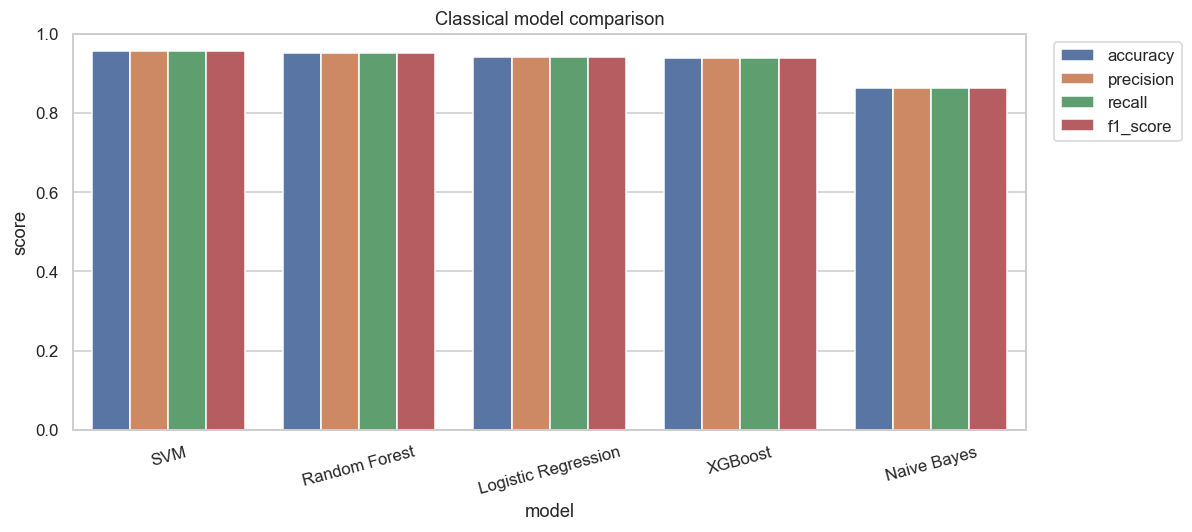

In [ ]:
metrics_melted = metrics_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1_score"],
                                  var_name="metric", value_name="score")

plt.figure(figsize=(11, 5))
sns.barplot(data=metrics_melted, x="model", y="score", hue="metric")
plt.title("Classical model comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/classical_model_comparison.png", bbox_inches="tight")
plt.show()


## 7. Top 10 TF-IDF features per label

In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_coefs  # captured during training (cell above) -- no need to reload the LR model

top10_true = pd.DataFrame({
    "feature": feature_names[np.argsort(coefs)[-10:][::-1]],
    "weight": np.sort(coefs)[-10:][::-1],
    "label": "True News",
})
top10_fake = pd.DataFrame({
    "feature": feature_names[np.argsort(coefs)[:10]],
    "weight": np.sort(coefs)[:10],
    "label": "Fake News",
})
top_features_df = pd.concat([top10_fake, top10_true], ignore_index=True)
top_features_df.to_csv(f"{TABLEAU_DIR}/top10_tfidf_features.csv", index=False)
top_features_df


,feature,weight,label
0,said,-16.480868,Fake News
1,breitbart,-13.605157,Fake News
2,president donald,-11.006113,Fake News
3,follow,-8.872600,Fake News
4,twitter,-7.017443,Fake News
5,thursday,-6.919375,Fake News
6,tuesday,-6.424181,Fake News
7,washington,-6.422721,Fake News
8,friday,-6.241866,Fake News
9,wednesday,-6.094298,Fake News


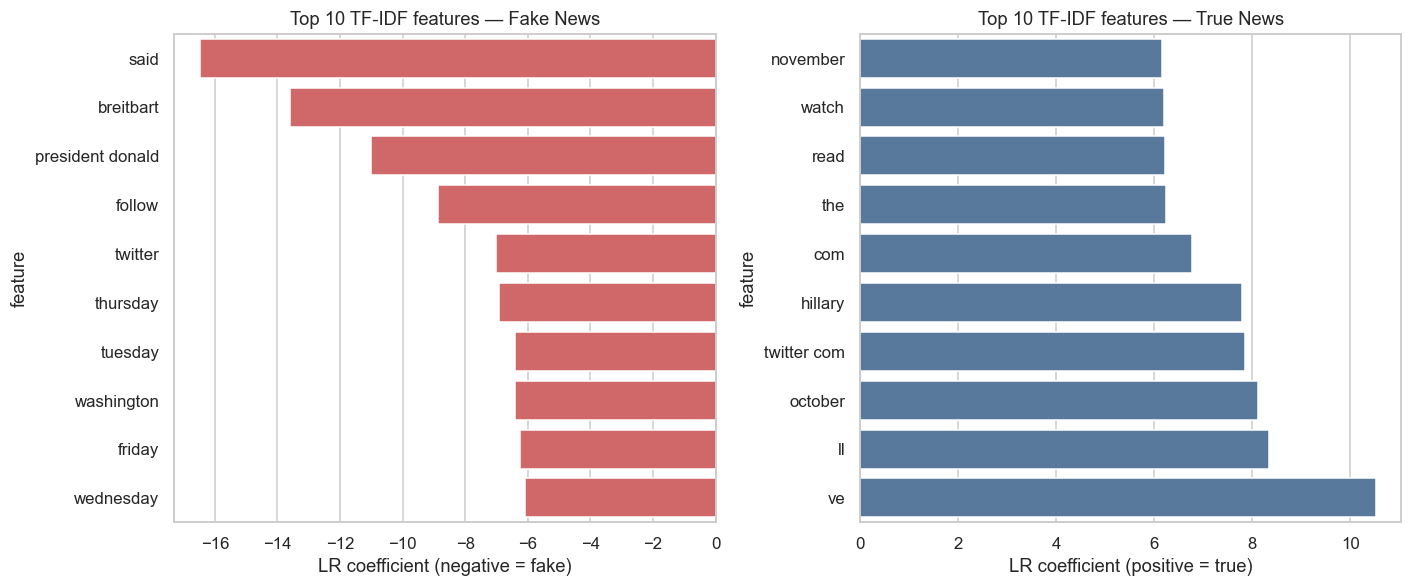

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.barplot(data=top10_fake.sort_values("weight"), x="weight", y="feature", ax=axes[0], color="#e15759")
axes[0].set_title("Top 10 TF-IDF features — Fake News")
axes[0].set_xlabel("LR coefficient (negative = fake)")

sns.barplot(data=top10_true.sort_values("weight"), x="weight", y="feature", ax=axes[1], color="#4e79a7")
axes[1].set_title("Top 10 TF-IDF features — True News")
axes[1].set_xlabel("LR coefficient (positive = true)")

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/top10_tfidf_features.png", bbox_inches="tight")
plt.show()


## 8. DistilBERT fine-tuning

In [ ]:
import torch
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    TrainingArguments, Trainer
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# DistilBERT uses the same cleaned text as the classical models but WITHOUT
# lemmatization (transformers work better on natural text).
bert_df = cleaned_df[["content", "label"]].rename(columns={"content": "text"})
bert_train_df, bert_test_df = train_test_split(
    bert_df, test_size=0.2, random_state=RANDOM_STATE, stratify=bert_df["label"]
)

train_ds = Dataset.from_pandas(bert_train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(bert_test_df.reset_index(drop=True))

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


Using device: cpu


Map: 100%|██████████| 14427/14427 [00:11<00:00, 1254.63 examples/s]


In [ ]:
bert_model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

training_args = TrainingArguments(
    output_dir=f"{REPORTS_DIR}/distilbert_checkpoints",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to=[],
)

# transformers renamed Trainer's `tokenizer` kwarg to `processing_class` in
# newer releases, and later removed the old name entirely -- Colab installs
# the latest version by default, so this can differ from what an older local
# pinned install (e.g. Windows) expects. Detect which this environment wants
# rather than hardcoding one or the other.
import inspect

trainer_kwargs = dict(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer_params = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_params:
    trainer_kwargs["tokenizer"] = tokenizer
else:
    print("Warning: this transformers version's Trainer accepts neither "
          "'tokenizer' nor 'processing_class' -- check for further API changes.")

trainer = Trainer(**trainer_kwargs)

trainer.train()


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3773.99it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss


In [ ]:
bert_eval = trainer.evaluate()
print(bert_eval)

bert_preds_logits = trainer.predict(test_ds).predictions
bert_preds = np.argmax(bert_preds_logits, axis=1)
print(classification_report(bert_test_df["label"], bert_preds, target_names=["Fake News", "True News"]))

bert_precision, bert_recall, bert_f1, _ = precision_recall_fscore_support(
    bert_test_df["label"], bert_preds, average="weighted"
)
bert_row = {
    "model": "DistilBERT",
    "accuracy": accuracy_score(bert_test_df["label"], bert_preds),
    "precision": bert_precision,
    "recall": bert_recall,
    "f1_score": bert_f1,
}
print(bert_row)


## 9. Final model comparison — all 6 models

In [ ]:
final_metrics_df = pd.concat([metrics_df, pd.DataFrame([bert_row])], ignore_index=True)
final_metrics_df = final_metrics_df.sort_values("f1_score", ascending=False).reset_index(drop=True)
final_metrics_df.to_csv(f"{REPORTS_DIR}/final_model_metrics.csv", index=False)
final_metrics_df.to_csv(f"{TABLEAU_DIR}/final_model_metrics.csv", index=False)

best_model_name = final_metrics_df.iloc[0]["model"]
print("Best model by weighted F1:", best_model_name)
final_metrics_df


In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=final_metrics_df, x="model", y="f1_score", palette="viridis")
plt.title(f"Model comparison (weighted F1) — best: {best_model_name}")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/final_model_comparison.png", bbox_inches="tight")
plt.show()


## 10. Additional performance charts — confusion matrices & ROC curves

In [ ]:
fig, axes = plt.subplots(1, len(predictions), figsize=(4.2 * len(predictions), 4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/confusion_matrices.png", bbox_inches="tight")
plt.show()


In [ ]:
plt.figure(figsize=(7, 6))
roc_rows = []
for name, y_score in roc_scores.items():  # precomputed during training -- no model objects needed here
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    roc_rows.append({"model": name, "auc": roc_auc})

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — classical models")
plt.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/roc_curves.png", bbox_inches="tight")
plt.show()

pd.DataFrame(roc_rows).to_csv(f"{TABLEAU_DIR}/roc_auc.csv", index=False)


## 11. Pickle each classical model as a self-contained `FakeNewsPredictor`

Each pickle bundles: cleaning (`strip_journalism_fingerprints`) + spaCy
lemmatization + the fitted TF-IDF vectorizer + the fitted classical model.
Loading the pickle and calling `.predict(raw_text)` returns
`{"label": int, "meaning": str, "confidence": float}` — no other setup needed
beyond having `fake_news_pipeline.py` importable.

In [ ]:
SAFE_NAME = {
    "Logistic Regression": "logistic_regression",
    "Naive Bayes": "naive_bayes",
    "SVM": "svm",
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
}

pickle_paths = {}
for name, path in model_paths.items():
    # reload one model at a time from disk -- at most one classical model is
    # ever fully resident in memory again, rather than all 5 simultaneously
    clf = joblib.load(path)

    predictor = fnp.FakeNewsPredictor(
        tfidf_vectorizer=tfidf,
        model=clf,
        model_name=name,
        spacy_model_name="en_core_web_sm",
        publishers_to_scrub=PUBLISHERS_TO_SCRUB,
        label_map=LABEL_MEANING,
    )
    out_path = f"{PICKLES_DIR}/{SAFE_NAME[name]}_pipeline.pkl"
    with open(out_path, "wb") as f:
        pickle.dump(predictor, f)
    pickle_paths[name] = out_path
    print("Saved:", out_path)

    del clf, predictor
    gc.collect()

# optional cleanup -- the temp .joblib files are now redundant with the
# bundled pickles above; uncomment to remove them once you've confirmed
# the bundled pickles load and predict correctly (see the sanity check below)
# import shutil
# shutil.rmtree(TMP_MODEL_DIR, ignore_errors=True)


### Sanity check — load a pickle back and predict on raw text

In [ ]:
with open(pickle_paths["Logistic Regression"], "rb") as f:
    loaded_predictor = pickle.load(f)

sample_text = "NEW YORK (Reuters) - Scientists announced a breakthrough today. [VIDEO] Featured image via Getty Images"
result = loaded_predictor.predict(sample_text)
print(result)

# swap to a different pickle file — same .predict() interface
with open(pickle_paths["XGBoost"], "rb") as f:
    loaded_xgb_predictor = pickle.load(f)
print(loaded_xgb_predictor.predict(sample_text))


## 12. Outputs summary

| Artifact | Path |
|---|---|
| Cleaned CSV | `CLEANED_CSV` |
| Lemmatized CSV | `PROCESSED_DIR/lemmatized_data.csv` |
| EDA data for Tableau | `TABLEAU_DIR/eda_summary.csv`, `eda_per_article.csv` |
| Classical model metrics | `TABLEAU_DIR/classical_model_metrics.csv` |
| Final comparison (incl. DistilBERT) | `TABLEAU_DIR/final_model_metrics.csv` |
| Top-10 TF-IDF features | `TABLEAU_DIR/top10_tfidf_features.csv` |
| ROC AUC values | `TABLEAU_DIR/roc_auc.csv` |
| Charts (PNG) | `CHARTS_DIR/*.png` |
| Pickled predictors | `PICKLES_DIR/*_pipeline.pkl` |
| Shared pipeline module | `PIPELINE_MODULE_PATH` |

Use the `streamlit_app.py` (delivered alongside this notebook) to serve any
of the pickles interactively — just change the model file path in the sidebar.
